In [1]:
# Libraries required
import os
# disable all debugging logs using os.environ
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import datetime

import IPython
import IPython.display

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import fnmatch
import tensorflow as tf


%matplotlib inline
# plt.rcParams['figure.figsize'] = [8, 6]
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.backend import square, mean
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError


from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error


# import warnings
# warnings.filterwarnings('ignore')
# warnings.filterwarnings(action='once')

In [2]:
!rm *.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station2_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station4_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station5_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station6_Revised_Final_Data.csv

rm: cannot remove '*.csv': No such file or directory


In [3]:
# TODO: Change later

def read_data():
    dfs = {}
    for index in range(0, 6):
        path = f'Station{index + 1}_Revised_Final_Data.csv'
        print(f"Reading: {path}")

        df = pd.read_csv(path, sep=",")
        df.columns = df.columns.str.replace(' ', '')  # Remove spaces in column names

        df.insert(0, 'Date', pd.to_datetime(df['Unnamed:0']))
        df = df.drop('Unnamed:0', axis=1).set_index('Date')

        columns_to_convert = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50', 'Ppt']
        for col in columns_to_convert:
            if col in df.columns:
                df[col] = df[col].astype(float)

        # Store in dictionary
        dfs[f'Station{index + 1}'] = df

    return dfs

# Execute function
dfs = read_data()

Reading: Station1_Revised_Final_Data.csv
Reading: Station2_Revised_Final_Data.csv
Reading: Station3_Revised_Final_Data.csv
Reading: Station4_Revised_Final_Data.csv
Reading: Station5_Revised_Final_Data.csv
Reading: Station6_Revised_Final_Data.csv


In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
# Read and set the index to be the date

df_soil = dfs['Station1']
df_soil

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 19:00:00,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,-0.490,100.0,2.086,43.56,0.00,30.3989,-98.6105
2020-12-31 20:00:00,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,-0.869,100.0,2.828,28.17,0.10,30.3989,-98.6105
2020-12-31 21:00:00,0.0,0.232,0.190,0.181,0.099,5.30,6.68,8.24,14.45,-0.895,99.9,2.230,85.10,1.06,30.3989,-98.6105


In [6]:
df_soil.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,0.068205,8.405104e-01,-1.464373,0.0000,0.0000,0.0000,40.640000
SWC_5,52560.0,0.140254,5.154907e-02,0.004612,0.0950,0.1340,0.1830,0.309000
SWC_10,52560.0,0.157113,4.093361e-02,-0.023168,0.1230,0.1540,0.1920,0.298000
SWC_20,52560.0,0.137294,3.346671e-02,0.049357,0.1050,0.1360,0.1650,0.235000
SWC_50,52560.0,0.137377,3.578278e-02,0.076554,0.1030,0.1290,0.1700,0.249000
T_5,52560.0,22.992845,9.495459e+00,0.760000,15.5500,22.9300,30.0800,49.960000
T_10,52560.0,23.007369,8.874525e+00,2.000000,15.8000,23.1100,30.1700,44.440000
T_20,52560.0,22.948400,8.384273e+00,3.270000,15.9400,23.0800,30.0100,41.200000
T_50,52560.0,22.805075,7.007613e+00,7.880000,16.5200,22.5900,29.2300,35.400000
Tair,52560.0,14.142881,2.328434e+01,-173.200000,11.5775,19.3300,24.4200,172.476413


In [7]:
# Check if Contains NaN values
df_soil.isnull().sum()

,0
Ppt,0
SWC_5,0
SWC_10,0
SWC_20,0
SWC_50,0
T_5,0
T_10,0
T_20,0
T_50,0
Tair,0


In [8]:
wv = df_soil.pop('Windspeed')
max_wv = np.max(wv)

# Convert to radians.
wd_rad = df_soil.pop('Winddirection')*np.pi / 180

# Calculate the wind x and y components.
df_soil['Wx'] = wv*np.cos(wd_rad)
df_soil['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df_soil['max Wx'] = max_wv*np.cos(wd_rad)
df_soil['max Wy'] = max_wv*np.sin(wd_rad)
df_soil

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Latitude,Longitude,Wx,Wy,max Wx,max Wy
Date,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,0.63,30.3989,-98.6105,0.643762,0.832030,5.017918,6.485406
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.62,30.3989,-98.6105,0.657578,0.698049,5.622669,5.968718
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,0.60,30.3989,-98.6105,0.653248,0.837324,5.043912,6.465211
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.64,30.3989,-98.6105,0.458032,0.759589,4.234348,7.022129
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.20,30.3989,-98.6105,0.793697,0.235857,7.860286,2.335786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 19:00:00,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,-0.490,100.0,0.00,30.3989,-98.6105,1.511626,1.437491,5.942156,5.650733
2020-12-31 20:00:00,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,-0.869,100.0,0.10,30.3989,-98.6105,2.493026,1.335068,7.228716,3.871132
2020-12-31 21:00:00,0.0,0.232,0.190,0.181,0.099,5.30,6.68,8.24,14.45,-0.895,99.9,1.06,30.3989,-98.6105,0.190480,2.221850,0.700419,8.170031


In [9]:
df=df_soil

(-7.567829061520954, 8.1975522162057, -4.273160359540029, 4.977053357534049)

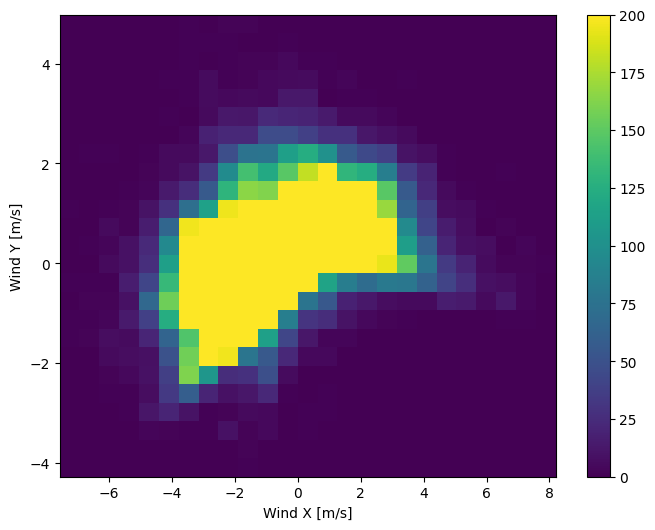

In [10]:
plt.hist2d(df['Wx'], df['Wy'], bins=(25, 25), vmax=200)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [11]:
df


,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Latitude,Longitude,Wx,Wy,max Wx,max Wy
Date,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,0.63,30.3989,-98.6105,0.643762,0.832030,5.017918,6.485406
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.62,30.3989,-98.6105,0.657578,0.698049,5.622669,5.968718
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,0.60,30.3989,-98.6105,0.653248,0.837324,5.043912,6.465211
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.64,30.3989,-98.6105,0.458032,0.759589,4.234348,7.022129
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.20,30.3989,-98.6105,0.793697,0.235857,7.860286,2.335786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 19:00:00,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,-0.490,100.0,0.00,30.3989,-98.6105,1.511626,1.437491,5.942156,5.650733
2020-12-31 20:00:00,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,-0.869,100.0,0.10,30.3989,-98.6105,2.493026,1.335068,7.228716,3.871132
2020-12-31 21:00:00,0.0,0.232,0.190,0.181,0.099,5.30,6.68,8.24,14.45,-0.895,99.9,1.06,30.3989,-98.6105,0.190480,2.221850,0.700419,8.170031


In [12]:
df = df.reset_index()
df

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Latitude,Longitude,Wx,Wy,max Wx,max Wy
0,2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,0.63,30.3989,-98.6105,0.643762,0.832030,5.017918,6.485406
1,2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.62,30.3989,-98.6105,0.657578,0.698049,5.622669,5.968718
2,2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,0.60,30.3989,-98.6105,0.653248,0.837324,5.043912,6.465211
3,2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.64,30.3989,-98.6105,0.458032,0.759589,4.234348,7.022129
4,2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.20,30.3989,-98.6105,0.793697,0.235857,7.860286,2.335786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,2020-12-31 19:00:00,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,-0.490,100.0,0.00,30.3989,-98.6105,1.511626,1.437491,5.942156,5.650733
52556,2020-12-31 20:00:00,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,-0.869,100.0,0.10,30.3989,-98.6105,2.493026,1.335068,7.228716,3.871132
52557,2020-12-31 21:00:00,0.0,0.232,0.190,0.181,0.099,5.30,6.68,8.24,14.45,-0.895,99.9,1.06,30.3989,-98.6105,0.190480,2.221850,0.700419,8.170031
52558,2020-12-31 22:00:00,0.0,0.229,0.189,0.181,0.099,5.29,6.55,8.09,14.31,-0.894,98.6,1.78,30.3989,-98.6105,-1.551655,0.746761,-7.388832,3.556004


In [13]:
# Convert to seconds
timestamp_s = df['Date'].map(pd.Timestamp.timestamp)
timestamp_s

,Date
0,1.420070e+09
1,1.420074e+09
2,1.420078e+09
3,1.420081e+09
4,1.420085e+09
...,...
52555,1.609441e+09
52556,1.609445e+09
52557,1.609448e+09
52558,1.609452e+09


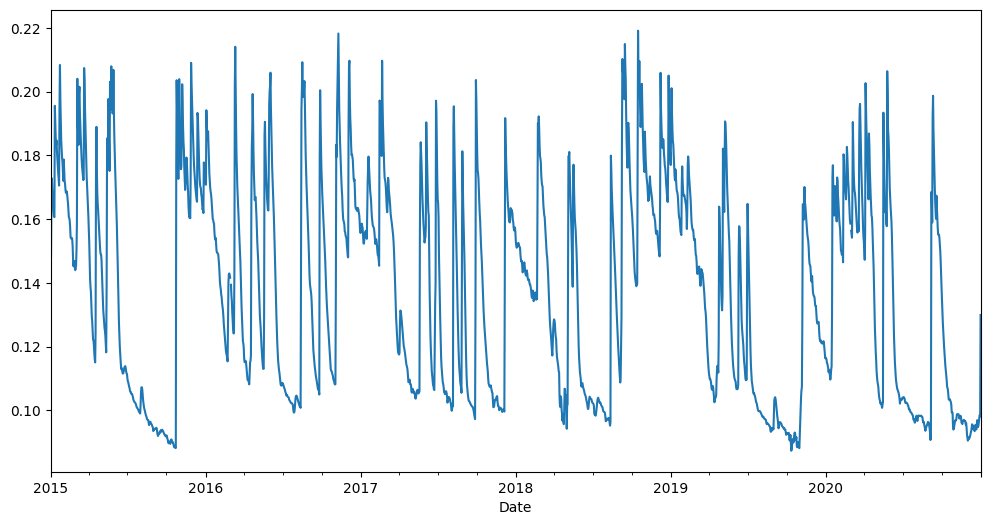

In [14]:
df_soil.SWC_20.resample('D').mean().plot(figsize=(12,6))
plt.show()

#observations:
#when does the data repeat? Where are the cycles?

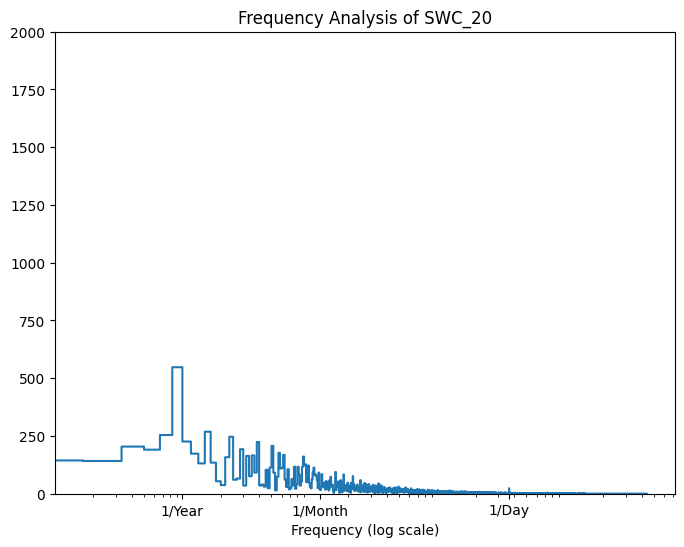

In [15]:
# using FFT - code gotten from tutorial

fft = tf.signal.rfft(df_soil['SWC_20'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df_soil['SWC_20'])
hours_per_year = 24 * 365.2524
years_per_dataset = n_samples_h / hours_per_year

f_per_year = f_per_dataset / years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 2000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 12, 365.2524], labels=['1/Year', '1/Month', '1/Day'])
plt.xlabel('Frequency (log scale)')
plt.title('Frequency Analysis of SWC_20')
plt.show()

In [16]:
# finding peaks in the data

import numpy as np

# Compute FFT and frequencies per year (already done)
fft = tf.signal.rfft(df_soil['SWC_20'])
f_per_dataset = np.arange(0, len(fft))
f_per_year = f_per_dataset / years_per_dataset

# Get amplitude (magnitude of FFT)
amplitude = np.abs(fft)

# Find significant peaks
from scipy.signal import find_peaks

# Find peaks with a minimum prominence (to ignore noise)
peaks, properties = find_peaks(amplitude, prominence=100)

# Get the frequencies and amplitudes of the peaks
peak_frequencies = f_per_year[peaks]
peak_amplitudes = amplitude[peaks]

# Print peaks
for freq, amp in zip(peak_frequencies, peak_amplitudes):
    print(f"Frequency: {freq:.2f} cycles/year, Amplitude: {amp:.2f}")


Frequency: 1.00 cycles/year, Amplitude: 547.59
Frequency: 1.67 cycles/year, Amplitude: 268.48
Frequency: 2.50 cycles/year, Amplitude: 246.59
Frequency: 3.00 cycles/year, Amplitude: 192.65
Frequency: 4.00 cycles/year, Amplitude: 223.84
Frequency: 5.17 cycles/year, Amplitude: 207.22
Frequency: 5.84 cycles/year, Amplitude: 176.93
Frequency: 9.01 cycles/year, Amplitude: 160.85


significant peaks at .33, 1, 1.67, 2.33, 3, 3.67

every 3 years, every year, .6 years, .42 years, .33 years, there are cycles


In [17]:
day = 24*60*60
year = (365.2425)*day
month = (365.2425/12)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))

df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

#talk to teymourian about this
df['Month sin'] = np.sin(timestamp_s * (2 * np.pi / month))
df['Month cos'] = np.cos(timestamp_s * (2 * np.pi / month))




df = df.drop(['Date'], axis=1)
df

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,...,Wx,Wy,max Wx,max Wy,Day sin,Day cos,Year sin,Year cos,Month sin,Month cos
0,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,...,0.643762,0.832030,5.017918,6.485406,1.232357e-12,1.000000,0.001505,0.999999,0.018062,0.999837
1,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,...,0.657578,0.698049,5.622669,5.968718,2.588190e-01,0.965926,0.002222,0.999998,0.026661,0.999645
2,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,...,0.653248,0.837324,5.043912,6.465211,5.000000e-01,0.866025,0.002939,0.999996,0.035258,0.999378
3,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,...,0.458032,0.759589,4.234348,7.022129,7.071068e-01,0.707107,0.003656,0.999993,0.043853,0.999038
4,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,...,0.793697,0.235857,7.860286,2.335786,8.660254e-01,0.500000,0.004372,0.999990,0.052444,0.998624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,0.0,0.242,0.193,0.182,0.099,5.46,6.95,8.62,14.71,-0.490,...,1.511626,1.437491,5.942156,5.650733,-9.659258e-01,0.258819,0.007297,0.999973,0.087450,0.996169
52556,0.0,0.236,0.191,0.182,0.099,5.43,6.80,8.40,14.58,-0.869,...,2.493026,1.335068,7.228716,3.871132,-8.660254e-01,0.500000,0.008014,0.999968,0.096015,0.995380
52557,0.0,0.232,0.190,0.181,0.099,5.30,6.68,8.24,14.45,-0.895,...,0.190480,2.221850,0.700419,8.170031,-7.071068e-01,0.707107,0.008730,0.999962,0.104573,0.994517
52558,0.0,0.229,0.189,0.181,0.099,5.29,6.55,8.09,14.31,-0.894,...,-1.551655,0.746761,-7.388832,3.556004,-5.000000e-01,0.866025,0.009447,0.999955,0.113124,0.993581


In [18]:
df.shape

(52560, 24)

Normalization


In [19]:
features_to_look_at = ['SWC_20', 'T_20', 'Day cos', 'Ppt'] #, 'Ppt', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos', 'Month sin', 'Month cos']

data = df[features_to_look_at]
data


,SWC_20,T_20,Day cos,Ppt
0,0.148,5.77,1.000000,0.0
1,0.148,5.71,0.965926,0.0
2,0.148,5.66,0.866025,0.0
3,0.148,5.62,0.707107,0.0
4,0.148,5.59,0.500000,0.0
...,...,...,...,...
52555,0.182,8.62,0.258819,0.0
52556,0.182,8.40,0.500000,0.0
52557,0.181,8.24,0.707107,0.0
52558,0.181,8.09,0.866025,0.0


(array([[5.2560e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 6.1200e+02, 4.1260e+03, 7.8010e+03, 7.9810e+03,
         7.7650e+03, 8.2260e+03, 7.8700e+03, 6.5000e+03, 1.6790e+03],
        [5.2560e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [5.2252e+04, 2.0300e+02, 4.3000e+01, 2.6000e+01, 6.0000e+00,
         1.4000e+01, 6.0000e+00, 4.0000e+00, 4.0000e+00, 2.0000e+00]]),
 array([-1.4643731 ,  2.80206421,  7.06850152, 11.33493883, 15.60137614,
        19.86781345, 24.13425076, 28.40068807, 32.66712538, 36.93356269,
        41.2       ]),
 <a list of 4 BarContainer objects>)

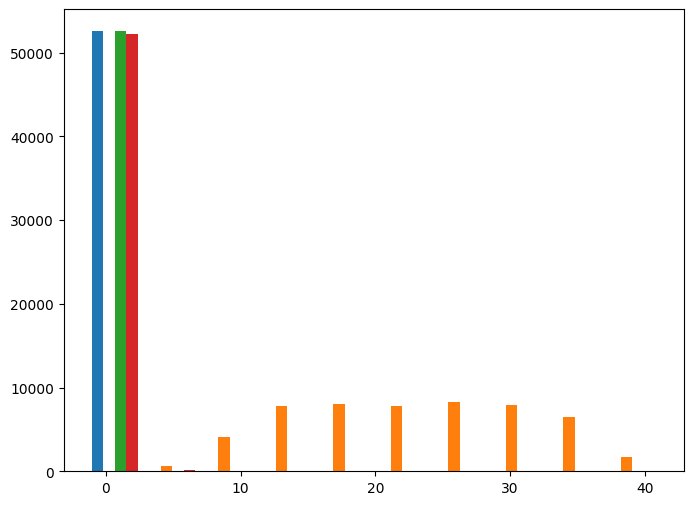

In [20]:
plt.hist(data)

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(data)
scaled_data = scaler.transform(data)
max = data.max(axis=0)
min = data.min(axis=0)

X_scaled = scaled_data

# scaler = MinMaxScaler()
# scaler.fit(data)
# scaled_data = scaler.transform(data)
# max = data.max(axis=0)
# min = data.min(axis=0)
# NORMALIZE THE DATA
# Min-Max normalization
# X_scaled = (data - min) / (max - min)
# X_scaled = X_std * (max - min) + min


In [22]:
X_scaled.max(), X_scaled.min()

(1.0, 0.0)

In [23]:
X_scaled.mean(), X_scaled.std()

(0.3822234303467553, 0.30300317205736593)

(array([[5.0000e+00, 1.1000e+01, 1.3707e+04, 9.1710e+03, 5.3000e+03,
         8.3340e+03, 9.8550e+03, 4.5110e+03, 1.5320e+03, 1.3400e+02],
        [6.1200e+02, 3.2870e+03, 6.9810e+03, 6.9160e+03, 6.9270e+03,
         7.3640e+03, 6.9680e+03, 7.1850e+03, 5.0630e+03, 1.2570e+03],
        [1.0950e+04, 4.3800e+03, 4.3800e+03, 4.3800e+03, 2.1910e+03,
         2.1890e+03, 4.3800e+03, 4.3800e+03, 4.3800e+03, 1.0950e+04],
        [5.2228e+04, 2.2700e+02, 4.0000e+01, 2.9000e+01, 6.0000e+00,
         1.3000e+01, 7.0000e+00, 3.0000e+00, 5.0000e+00, 2.0000e+00]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 4 BarContainer objects>)

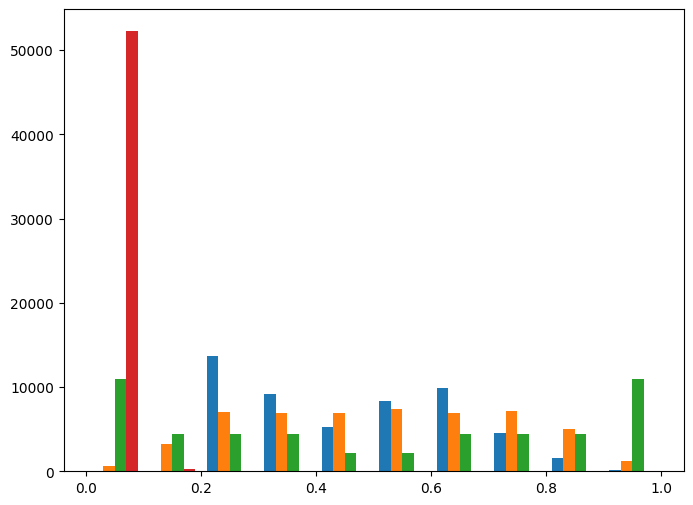

In [24]:
plt.hist(X_scaled)

Now all values are between 0 and 1. But have the same shape.


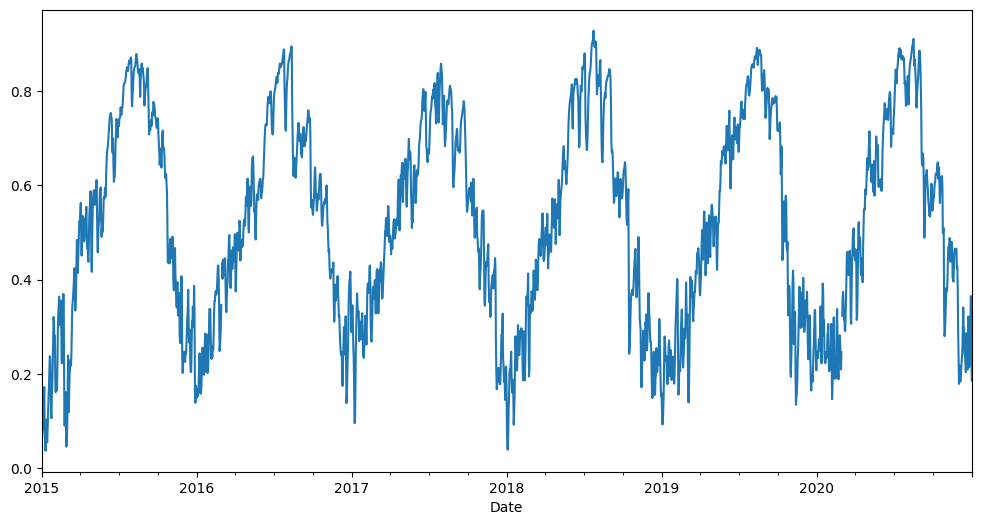

In [25]:
X_scaled_series = pd.Series(X_scaled[:, 1], index=df_soil.index[:len(X_scaled)]) # looking at temp

X_scaled_series.resample('D').mean().plot(figsize=(12,6))
plt.show()



In [26]:
def data_to_X_y(data, window_size=24 * 7, offset=24):
    data_as_np = np.array(data)
    X=[]
    y=[]
    for i in range(len(data_as_np) - window_size - offset):
        row = [a for a in data_as_np[i:i+window_size, :]]
        X.append(row)
        label=data_as_np[i + window_size + offset, 0]
        y.append(label)
    return np.array(X), np.array(y)


################
window_size = 7*24
offset=7*24
X, y = data_to_X_y(X_scaled, 168, 24)
print(X[122], y[122])
X.shape, y.shape

[[0.63909129 0.10150277 0.9330127  0.0347796 ]
 [0.63909129 0.09649354 0.85355339 0.0347796 ]
 [0.6337046  0.09253889 0.75       0.0347796 ]
 [0.6337046  0.08884788 0.62940952 0.0347796 ]
 [0.6337046  0.08542051 0.5        0.0347796 ]
 [0.6337046  0.08278408 0.37059048 0.0347796 ]
 [0.6337046  0.07935671 0.25       0.0347796 ]
 [0.6283179  0.07672027 0.14644661 0.0347796 ]
 [0.6283179  0.07592934 0.0669873  0.0347796 ]
 [0.6337046  0.08199315 0.01703709 0.0347796 ]
 [0.6337046  0.09649354 0.         0.0347796 ]
 [0.6337046  0.11811231 0.01703709 0.0347796 ]
 [0.63909129 0.14447667 0.0669873  0.0347796 ]
 [0.64447799 0.17268653 0.14644661 0.0347796 ]
 [0.64447799 0.19931453 0.25       0.0347796 ]
 [0.64986469 0.2209333  0.37059048 0.0347796 ]
 [0.64986469 0.23385183 0.5        0.0347796 ]
 [0.64986469 0.23807013 0.62940952 0.0347796 ]
 [0.64986469 0.23543369 0.75       0.0347796 ]
 [0.64986469 0.2288426  0.85355339 0.0347796 ]
 [0.64447799 0.22119694 0.9330127  0.0347796 ]
 [0.64447799 

((52368, 168, 4), (52368,))

In [27]:
#understand this
time_data = tf.keras.utils.timeseries_dataset_from_array(data, targets=None,
                                                      sequence_length = window_size,
                                                      sequence_stride=1,
                                                      sampling_rate=1,
                                                      batch_size=32,
                                                      shuffle=False,
                                                      seed=None,
                                                      start_index=None,
                                                      end_index=None,
                                                      )
# time_data

counter = 0
for batch in time_data:
    print(batch)




Streaming output truncated to the last 5000 lines.
tf.Tensor(
[[[ 9.90000000e-02  3.85900000e+01 -5.00000000e-01  0.00000000e+00]
  [ 1.00000000e-01  3.95100000e+01 -2.58819045e-01  0.00000000e+00]
  [ 1.00000000e-01  4.01500000e+01 -4.31705124e-12  0.00000000e+00]
  ...
  [ 9.40000000e-02  3.30800000e+01 -9.65925826e-01  0.00000000e+00]
  [ 9.50000000e-02  3.41000000e+01 -8.66025404e-01  0.00000000e+00]
  [ 9.60000000e-02  3.52000000e+01 -7.07106781e-01  0.00000000e+00]]

 [[ 1.00000000e-01  3.95100000e+01 -2.58819045e-01  0.00000000e+00]
  [ 1.00000000e-01  4.01500000e+01 -4.31705124e-12  0.00000000e+00]
  [ 1.00000000e-01  4.04800000e+01  2.58819045e-01  0.00000000e+00]
  ...
  [ 9.50000000e-02  3.41000000e+01 -8.66025404e-01  0.00000000e+00]
  [ 9.60000000e-02  3.52000000e+01 -7.07106781e-01  0.00000000e+00]
  [ 9.60000000e-02  3.61800000e+01 -5.00000000e-01  0.00000000e+00]]

 [[ 1.00000000e-01  4.01500000e+01 -4.31705124e-12  0.00000000e+00]
  [ 1.00000000e-01  4.04800000e+01  2.

In [28]:
n = len(X)

#todo: test on exact year of data.
X_train, y_train = X[0:int(n*0.7)],y[0:int(n*0.7)]
X_val, y_val = X[int(n*0.7):int(n*0.9)], y[int(n*0.7):int(n*0.9)]
X_test, y_test = X[int(n*0.9):], y[int(n*0.9):]

print(X_train.size, X_val.size, X_test.size)
y_train.size, y_val.size, y_test.size

24633504 7038528 3519264


(36657, 10474, 5237)

Trying to use and understand this function -
tf.keras.utils.timeseries_dataset_from_array

In [29]:
# #TIMESERIES_DATASET_FROM_ARRAY (not to be used)
# window_size = 7 * 24  # 1 week of hourly data
# offset = 24           # Predict 24 hours ahead
# sequence_stride = 1    # Move window by 1 step each time

# # Specify targets (e.g., SWC_20 column after scaling)
# targets = scaled_data[:, 0]  # Assuming SWC_20 is the first column


# # Compute the number of samples
# n_samples = len(scaled_data) - window_size - offset

# # Split indices
# train_size = int(0.7 * n_samples)
# val_size = int(0.2 * n_samples)

# # Create datasets
# train_dataset = tf.keras.utils.timeseries_dataset_from_array(
#     data=scaled_data[:train_size + window_size],
#     targets=targets[:train_size + window_size],
#     sequence_length=window_size,
#     sequence_stride=sequence_stride,
#     batch_size=32,
#     shuffle=True
# )

# val_dataset = tf.keras.utils.timeseries_dataset_from_array(
#     data=scaled_data[train_size:train_size + val_size + window_size],
#     targets=targets[train_size:train_size + val_size + window_size],
#     sequence_length=window_size,
#     sequence_stride=sequence_stride,
#     batch_size=32,
#     shuffle=False
# )

# test_dataset = tf.keras.utils.timeseries_dataset_from_array(
#     data=scaled_data[train_size + val_size:],
#     targets=targets[train_size + val_size:],
#     sequence_length=window_size,
#     sequence_stride=sequence_stride,
#     batch_size=32,
#     shuffle=False
# )


In [30]:
model = Sequential()
model.add(InputLayer((24*7, X.shape[2])))
model.add(LSTM(32))
model.add(Dense(8, 'relu'))
model.add(Dense(1, 'linear'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,009 (19.57 KB)

 Trainable params: 5,009 (19.57 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
cp = ModelCheckpoint('model1.keras', save_best_only=True)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')

model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [32]:
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     callbacks=[cp, early_stopping]
# )
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, callbacks=[cp, early_stopping])

Epoch 1/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.0619 - root_mean_squared_error: 0.2316 - val_loss: 0.0039 - val_root_mean_squared_error: 0.0627
Epoch 2/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0045 - root_mean_squared_error: 0.0669 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0589
Epoch 3/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0045 - root_mean_squared_error: 0.0668 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0560
Epoch 4/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0040 - root_mean_squared_error: 0.0636 - val_loss: 0.0030 - val_root_mean_squared_error: 0.0548
Epoch 5/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0038 - root_mean_squared_error: 0.0618 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0543
Epoch 6/20
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0037 - root_mean_squared_error: 0.0612 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0532
Epoch 7/20
1146/1146 ━━━━━━━

In [33]:
from tensorflow.keras.models import load_model
model=load_model('model1.keras')


In [34]:
history.history

{'loss': [0.021946752443909645,
  0.004419517703354359,
  0.004081552382558584,
  0.003881227457895875,
  0.003750748233869672,
  0.0036728959530591965,
  0.0035905675031244755,
  0.0035437867045402527,
  0.0035028306301683187,
  0.0034473384730517864,
  0.0034226824063807726,
  0.00337985809892416,
  0.0033443488646298647,
  0.0033164178021252155,
  0.0032982078846544027],
 'root_mean_squared_error': [0.14814436435699463,
  0.06647945195436478,
  0.06388702988624573,
  0.06229949742555618,
  0.06124335154891014,
  0.06060442328453064,
  0.05992134287953377,
  0.059529710561037064,
  0.059184715151786804,
  0.058714039623737335,
  0.05850369483232498,
  0.05813654512166977,
  0.05783034488558769,
  0.05758834630250931,
  0.057430025190114975],
 'val_loss': [0.003927514888346195,
  0.0034633667673915625,
  0.0031398774590343237,
  0.0030027537140995264,
  0.002949367742985487,
  0.0028292322531342506,
  0.0029725402127951384,
  0.002709553577005863,
  0.002784632844850421,
  0.002703623

Text(0.5, 1.0, 'Training and Validation Loss')

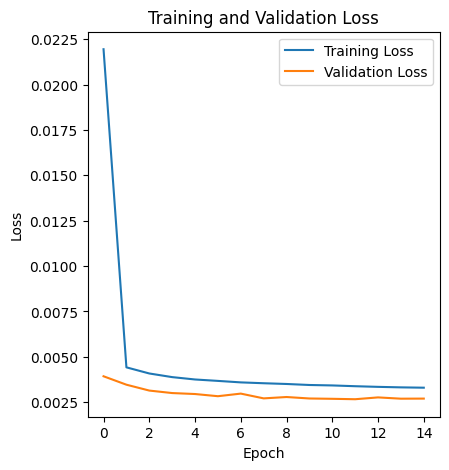

In [35]:
# Extract training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extract training and validation accuracy (if available)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

In [36]:
test_predictions = model.predict(X_test).flatten()
test_predictions
print(test_predictions.size)
print(y_test.size)
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
5237
5237


,Test Predictions,Actuals
0,0.773399,0.736052
1,0.769546,0.730665
2,0.765048,0.725278
3,0.759969,0.725278
4,0.754430,0.730665
...,...,...
5232,0.315895,0.714505
5233,0.317015,0.714505
5234,0.317495,0.709118
5235,0.317383,0.709118


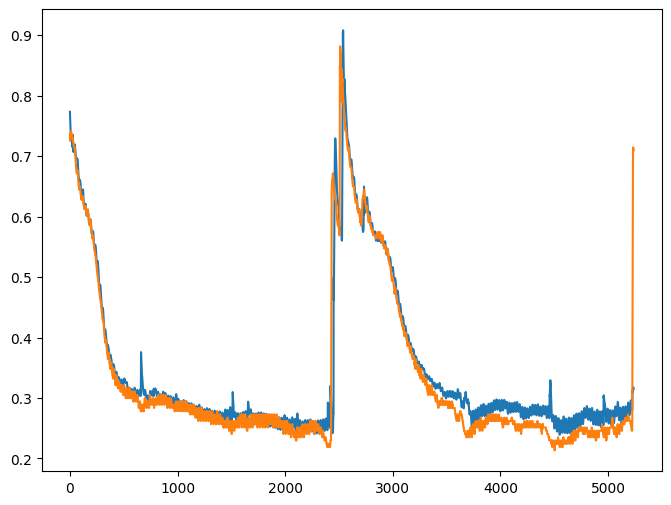

In [37]:
plt.plot(test_results['Test Predictions'])
plt.plot(test_results['Actuals'])

In [38]:
y_true = test_results['Actuals']
y_pred = test_results['Test Predictions']

r2_score(y_true, y_pred)

0.9130395673259247

In [39]:
mean_squared_error(y_true, y_pred)

0.001656753035192764

In [40]:
mean_absolute_percentage_error(y_true, y_pred)

0.062145658250862275

NEW MODEL

In [42]:
!pip install keras-self-attention


  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=4545de049c4ae56bbb11eb13f12628dd77a2f2853e279d9f4df524ffe38355e0
  Stored in directory: /root/.cache/pip/wheels/46/f9/96/709295c836133071c12a300729fed4027757f889c01695feea
Successfully built keras-self-attention


In [57]:
from keras_self_attention import SeqSelfAttention  # Ensure you have keras-self-attention installed

# Define the new model with LSTM and attention
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(24*7, X.shape[2])),
    tf.keras.layers.LSTM(32, return_sequences=True),  # Ensure return_sequences=True for attention
    SeqSelfAttention(attention_activation='softmax'),  # Attention layer
    tf.keras.layers.LSTM(32),  # Normal LSTM after attention
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')  # Kept linear activation as in original model
])

# Display model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 168, 32)             │           4,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ seq_self_attention_1                 │ (None, 168, 32)             │           2,113 │
│ (SeqSelfAttention)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,442 (60.32 KB)

 Trainable params: 15,442 (60.32 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
cp = ModelCheckpoint('model1.keras', save_best_only=True)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')

model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [59]:
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     callbacks=[cp, early_stopping]
# )
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp, early_stopping])

Epoch 1/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - loss: 0.0142 - root_mean_squared_error: 0.1177 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0892
Epoch 2/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 0.0105 - root_mean_squared_error: 0.1022 - val_loss: 0.0074 - val_root_mean_squared_error: 0.0858
Epoch 3/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - loss: 0.0101 - root_mean_squared_error: 0.1003 - val_loss: 0.0053 - val_root_mean_squared_error: 0.0725
Epoch 4/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - loss: 0.0062 - root_mean_squared_error: 0.0790 - val_loss: 0.0046 - val_root_mean_squared_error: 0.0677
Epoch 5/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 0.0059 - root_mean_squared_error: 0.0766 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0662
Epoch 6/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - loss: 0.0051 - root_mean_squared_error: 0.0713 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0649
Epoch 7/10
1146/1146 ━━━━━━━

In [60]:
from tensorflow.keras.models import load_model
model=load_model('model1.keras')


In [61]:
history.history

{'loss': [0.01155434176325798,
  0.010624159127473831,
  0.008759758435189724,
  0.006181037984788418,
  0.0056008691899478436,
  0.005167627241462469,
  0.004999988712370396,
  0.0049540214240550995,
  0.005359547212719917],
 'root_mean_squared_error': [0.10749112069606781,
  0.10307355970144272,
  0.09359358251094818,
  0.0786195769906044,
  0.07483895868062973,
  0.07188621163368225,
  0.07071059942245483,
  0.07038480788469315,
  0.07320892810821533],
 'val_loss': [0.007957922294735909,
  0.00736933434382081,
  0.005250561982393265,
  0.0045887744054198265,
  0.004379361867904663,
  0.004216399975121021,
  0.0042616231366992,
  0.004485125653445721,
  0.004338277969509363],
 'val_root_mean_squared_error': [0.08920718729496002,
  0.08584482222795486,
  0.07246076315641403,
  0.06774049252271652,
  0.06617674976587296,
  0.06493381410837173,
  0.06528110802173615,
  0.0669710785150528,
  0.06586560606956482]}

Text(0.5, 1.0, 'Training and Validation Loss')

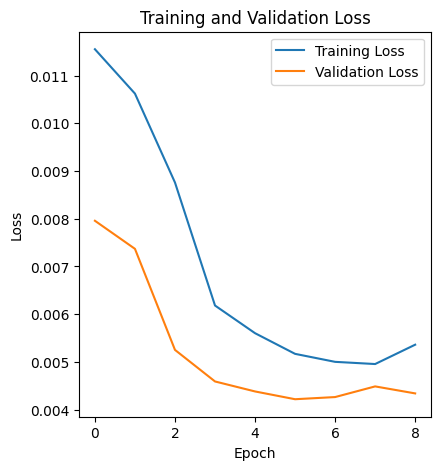

In [62]:
# Extract training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extract training and validation accuracy (if available)
train_acc = history.history.get('accuracy', None)
val_acc = history.history.get('val_accuracy', None)

# Plot loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

In [63]:
test_predictions = model.predict(X_test).flatten()
test_predictions
print(test_predictions.size)
print(y_test.size)
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results

164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
5237
5237


,Test Predictions,Actuals
0,0.761867,0.736052
1,0.761657,0.730665
2,0.761153,0.725278
3,0.760365,0.725278
4,0.759312,0.730665
...,...,...
5232,0.266390,0.714505
5233,0.267741,0.714505
5234,0.269157,0.709118
5235,0.270532,0.709118


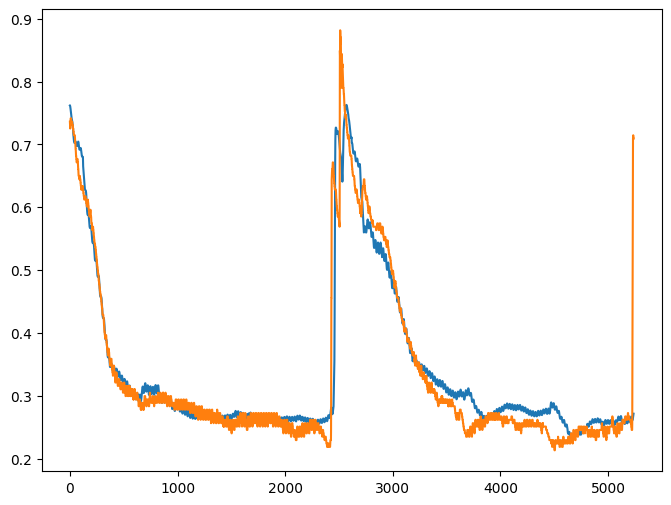

In [64]:
plt.plot(test_results['Test Predictions'])
plt.plot(test_results['Actuals'])

In [65]:
y_true = test_results['Actuals']
y_pred = test_results['Test Predictions']

r2_score(y_true, y_pred)

0.9036125163589368

In [66]:
mean_squared_error(y_true, y_pred)

0.0018363553534219174

In [ ]:
mean_absolute_percentage_error(y_true, y_pred)